#**Projeto Premier League – Data Lake (Raw, Cleaned, Curated)**

##**Aluno: Lucas Barbosa dos Santos**

##criei os 3 buckets no S3:
###1.   raw-zone-731084
###2.   cleaned-zone-731084
###3.   curated-zone-731084






## 1. Criação da Raw Zone
- Criação manual do bucket raw-zone-731084.
- Inserção dos dados brutos sem transformações.

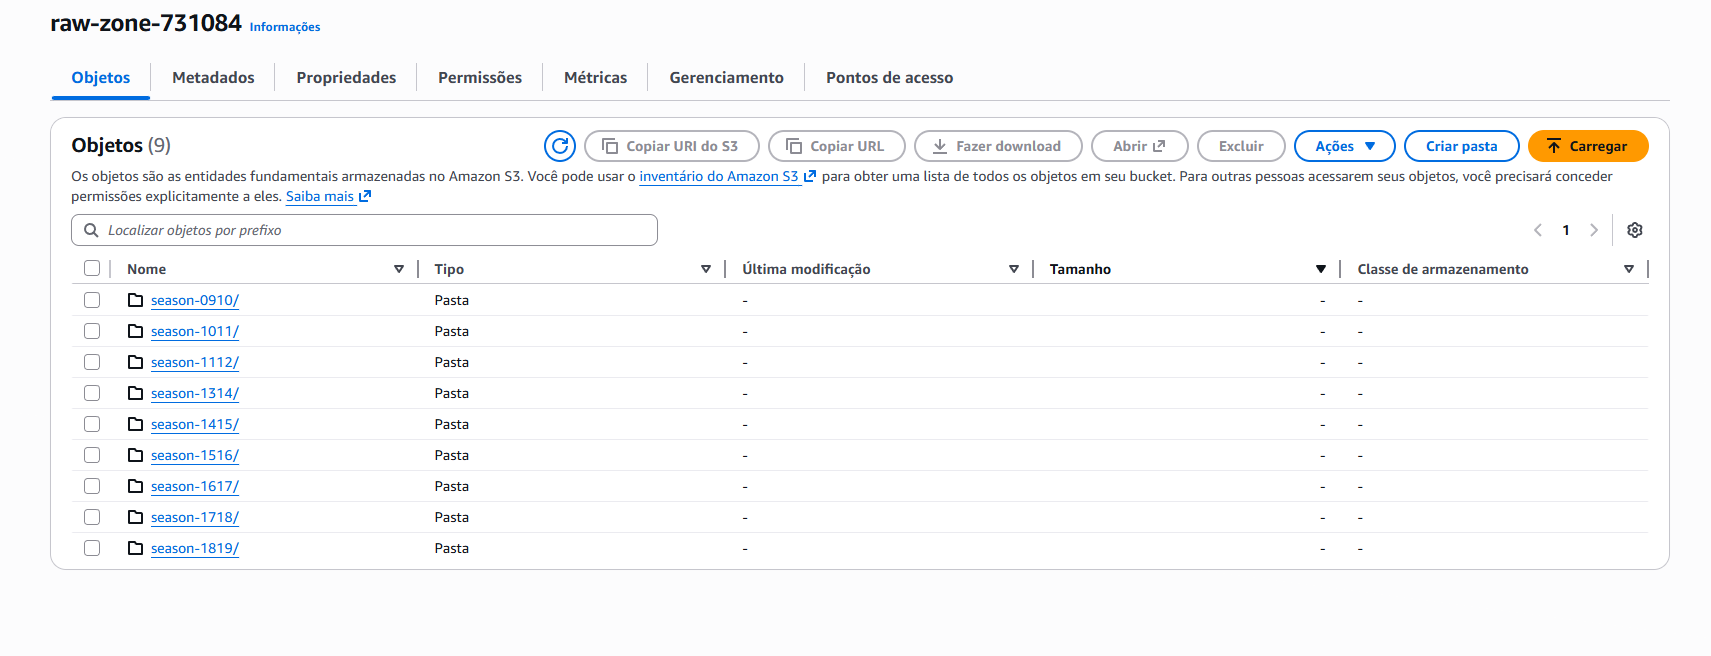


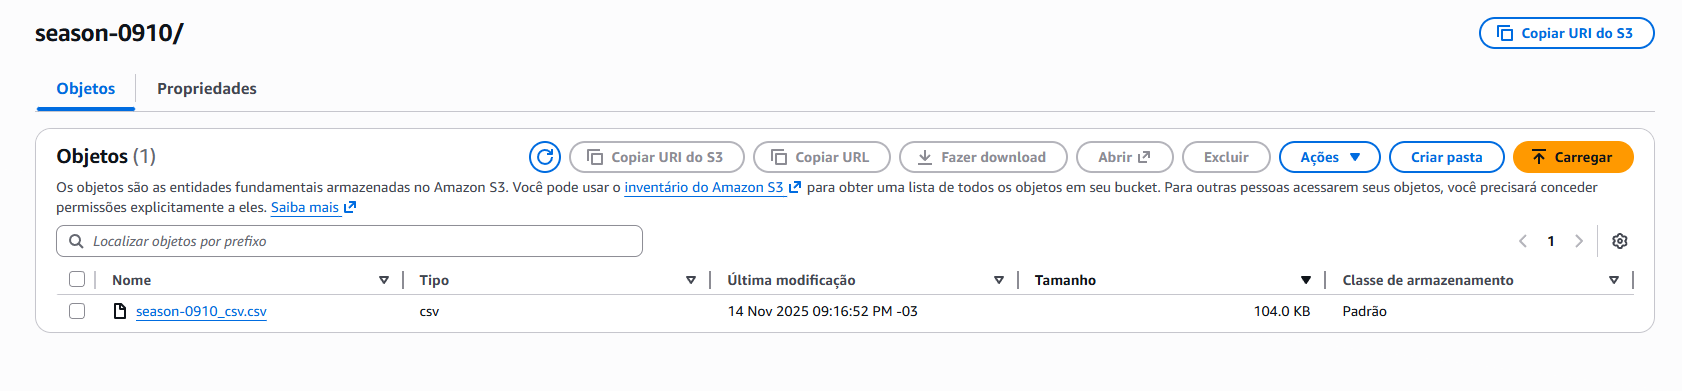


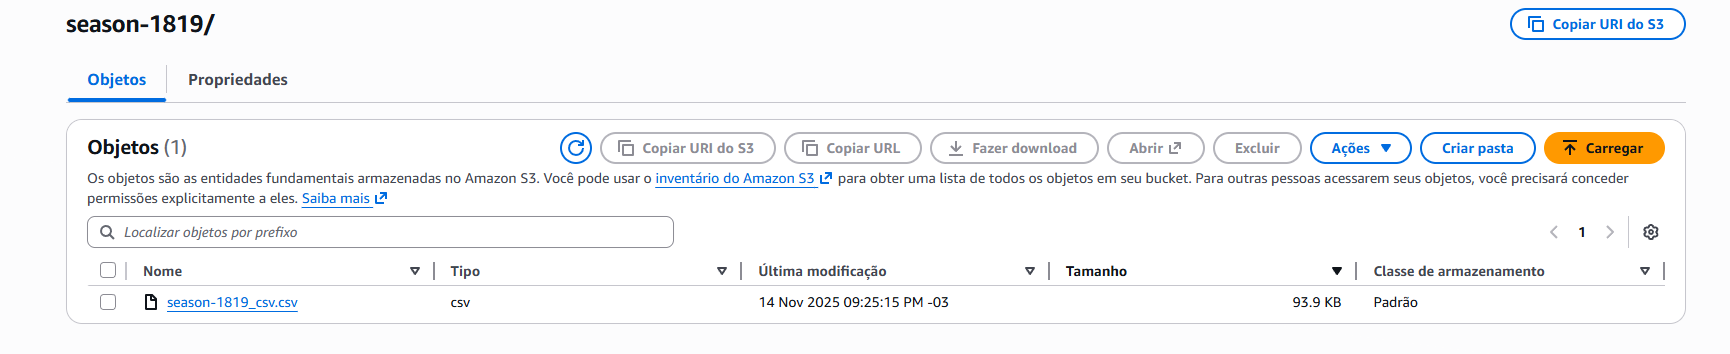

##2. Processamento inicial em Python

In [ ]:
import os
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks/English Premier League (football) 10 Seasons'

Mounted at /content/drive


In [ ]:
files = [f for f in os.listdir(file_path) if f.endswith(".csv")]

unique_columns = set()

for f in files:
    df = pd.read_csv(os.path.join(file_path, f))
    unique_columns.update(df.columns)

print("TOTAL DE COLUNAS ÚNICAS:", len(unique_columns))
print("\nLISTA COMPLETA DE COLUNAS:")
for col in sorted(unique_columns):
    print(col)

TOTAL DE COLUNAS ÚNICAS: 77

LISTA COMPLETA DE COLUNAS:
AC
AF
AR
AS
AST
AY
AwayTeam
B365A
B365D
B365H
BSA
BSD
BSH
BWA
BWD
BWH
Bb1X2
BbAH
BbAHh
BbAv<2.5
BbAv>2.5
BbAvA
BbAvAHA
BbAvAHH
BbAvD
BbAvH
BbMx<2.5
BbMx>2.5
BbMxA
BbMxAHA
BbMxAHH
BbMxD
BbMxH
BbOU
Date
Div
FTAG
FTHG
FTR
GBA
GBD
GBH
HC
HF
HR
HS
HST
HTAG
HTHG
HTR
HY
HomeTeam
IWA
IWD
IWH
LBA
LBD
LBH
PSA
PSCA
PSCD
PSCH
PSD
PSH
Referee
SBA
SBD
SBH
SJA
SJD
SJH
VCA
VCD
VCH
WHA
WHD
WHH


## -> Remoção de colunas irrelevantes.
## -> Remoção de dados nulos.
## -> Criação da coluna season.

In [ ]:
# colunas desejadas
keep_cols = ["FTAG", "FTHG", "Date", "AwayTeam", "HomeTeam"]

for f in files:
    full_path = os.path.join(file_path, f)

    # Lê CSV com todos os tipos como string (evita problemas)
    df = pd.read_csv(full_path, dtype=str)

    # Extrair season do nome (sempre 4 dígitos)
    season = f.split("-")[1].split("_")[0].zfill(4)
    df["season"] = season

    # Mantém só as colunas desejadas
    df = df[keep_cols + ["season"]]

    # Preenche nulos com string vazia
    df = df.fillna("")

    # Salvar tratado
    output_path = os.path.join(file_path, f"cleaned_{f}")
    df.to_csv(output_path, index=False)

    print(f"✔ Arquivo limpo: cleaned_{f}")

✔ Arquivo limpo: cleaned_season-1314_csv.csv
✔ Arquivo limpo: cleaned_season-1112_csv.csv
✔ Arquivo limpo: cleaned_season-1718_csv.csv
✔ Arquivo limpo: cleaned_season-1213_csv.csv
✔ Arquivo limpo: cleaned_season-0910_csv.csv
✔ Arquivo limpo: cleaned_season-1819_csv.csv
✔ Arquivo limpo: cleaned_season-1516_csv.csv
✔ Arquivo limpo: cleaned_season-1415_csv.csv
✔ Arquivo limpo: cleaned_season-1011_csv.csv
✔ Arquivo limpo: cleaned_season-1617_csv.csv


##**Problema com a leitura da coluna season pelo Pandas e impacto no catálogo AWS**

Durante o pré-processamento dos dados das temporadas da Premier League, surgiu um problema relacionado à temporada 0910. Mesmo tratando a coluna season como string, o Pandas removia o zero à esquerda ao ler ou salvar o arquivo, convertendo o valor "0910" em "910".

Isso ocorre porque o Pandas tenta inferir automaticamente o tipo da coluna, e valores numéricos iniciados por zero são interpretados como inteiros. Como inteiros não preservam zeros à esquerda, a informação era automaticamente modificada.
Assim:

"0910" → interpretado como inteiro → 910

ao salvar, o valor permanecia sem o zero inicial.

Esse detalhe, apesar de parecer simples, causou problemas no catálogo do AWS Glue.
Como o valor da temporada era utilizado como partição, a inconsistência entre "0910" e "910" fazia o catálogo gerar:

pastas com nomes incorretos,

partições faltando ou com nome diferente do esperado,

erros ao carregar partições, como _HIVE_PARTITION_SCHEMA_MISMATCH,

divergência entre estrutura física no S3 e o schema lido pelo Glue.

Além disso, o Athena não reconhecia a temporada corretamente, pois os metadados esperavam o valor textual "0910", mas encontravam "910" no S3, quebrando consultas ou retornando resultados vazios.

Para contornar o problema, foi adotada uma solução provisória: renomear temporariamente a temporada para “S910”, garantindo que o Pandas tratasse o valor como texto e não removesse o zero à esquerda.
Posteriormente, na etapa de ETL no AWS Glue, o valor foi padronizado de volta para o formato correto antes de gerar os arquivos Parquet.

Essa correção garantiu:

consistência entre o valor lógico da temporada,

nomes adequados das partições no S3,

e funcionamento adequado do catálogo e das consultas no Athena.

In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/English Premier League (football) 10 Seasons/cleaned_season-0910_csv.csv')
df.head()

,FTAG,FTHG,Date,AwayTeam,HomeTeam,season
0,2,0,2009-08-15,Wigan,Aston Villa,910
1,2,0,2009-08-15,Man City,Blackburn,910
2,1,0,2009-08-15,Sunderland,Bolton,910
3,1,2,2009-08-15,Hull,Chelsea,910
4,6,1,2009-08-15,Arsenal,Everton,910


In [ ]:
df['season']="S910"
df.head()

,FTAG,FTHG,Date,AwayTeam,HomeTeam,season
0,2,0,2009-08-15,Wigan,Aston Villa,S910
1,2,0,2009-08-15,Man City,Blackburn,S910
2,1,0,2009-08-15,Sunderland,Bolton,S910
3,1,2,2009-08-15,Hull,Chelsea,S910
4,6,1,2009-08-15,Arsenal,Everton,S910


In [ ]:
df1 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/English Premier League (football) 10 Seasons/cleaned_season-1011_csv.csv')
df1.head()

,FTAG,FTHG,Date,AwayTeam,HomeTeam,season
0,0,3,14/08/10,West Ham,Aston Villa,1011
1,0,1,14/08/10,Everton,Blackburn,1011
2,0,0,14/08/10,Fulham,Bolton,1011
3,0,6,14/08/10,West Brom,Chelsea,1011
4,2,2,14/08/10,Birmingham,Sunderland,1011


## O formato da coluna Date para a season 0910 em comparação ao resto do dataset tá em uma formatação diferente o que tambem afetava o catálogo nas partições

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

# Formatando para o padrão DD/MM/YY
df['Date'] = df['Date'].dt.strftime('%d/%m/%y')

In [ ]:
df.head()

,FTAG,FTHG,Date,AwayTeam,HomeTeam,season
0,2,0,15/08/09,Wigan,Aston Villa,S910
1,2,0,15/08/09,Man City,Blackburn,S910
2,1,0,15/08/09,Sunderland,Bolton,S910
3,1,2,15/08/09,Hull,Chelsea,S910
4,6,1,15/08/09,Arsenal,Everton,S910


In [ ]:
df.to_csv('/content/drive/My Drive/Colab Notebooks/English Premier League (football) 10 Seasons/cleaned_season-0910_csv.csv', index=False)
print(f"✔ Arquivo limpo: cleaned_season-0910")

✔ Arquivo limpo: cleaned_season-0910


## 3. Cleaned Zone – ETL no AWS Glue
- Criei uma pasta chamada `cleaned-seasons` e adicionei ao `raw-bucket-731084`
- Catalogação da pasta `cleaned-seasons`.
- Criação do ETL visual:
  - Partições: `season`, `awayteam`, `date`.
  - Conversão para Parquet.
- Catalogação final gerando tabela única no Athena.

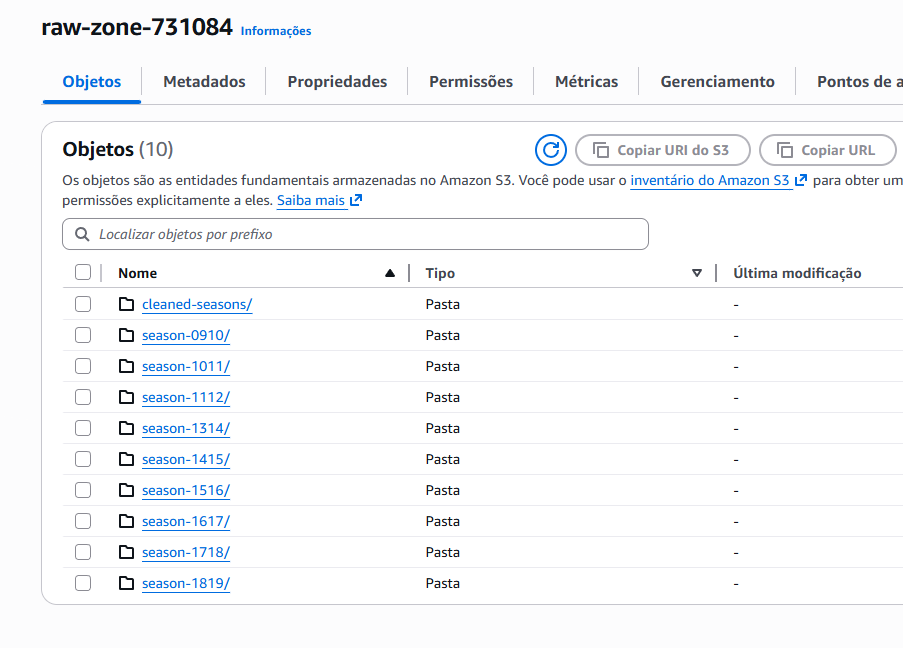

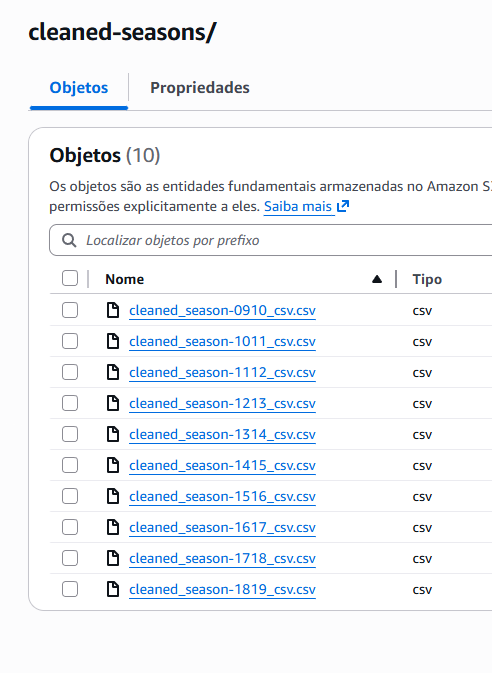

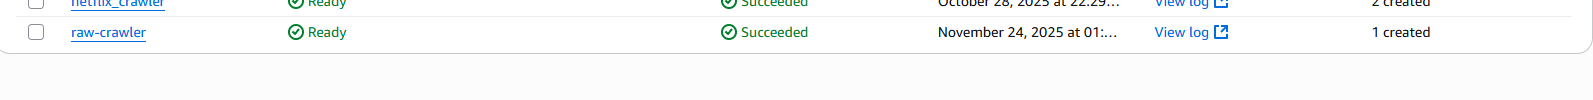

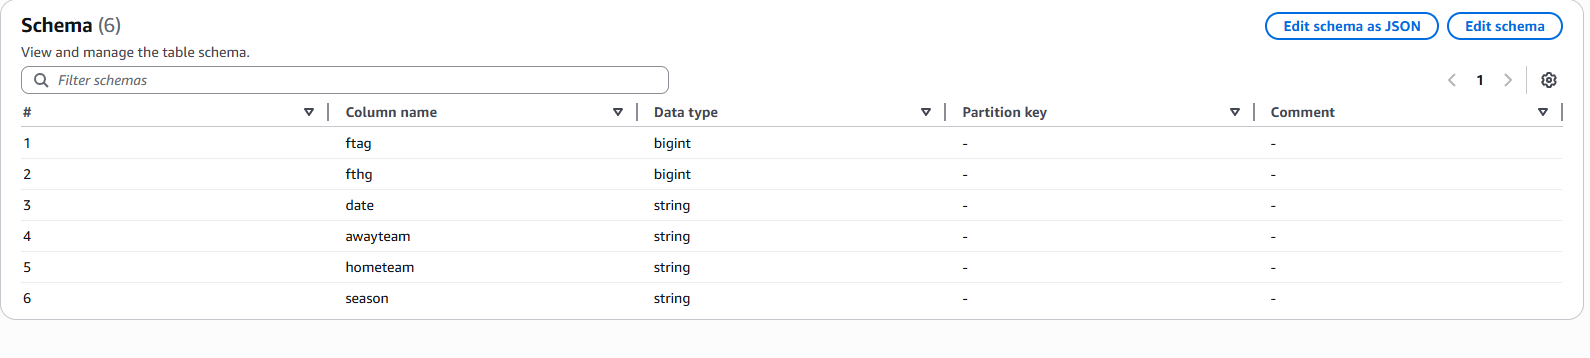

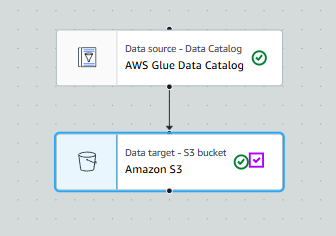

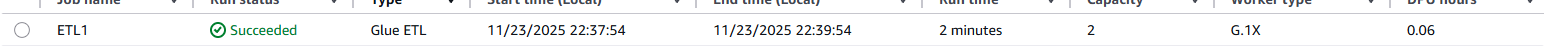

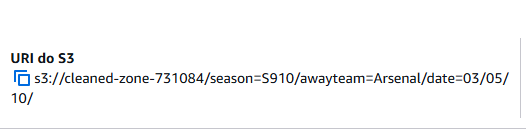

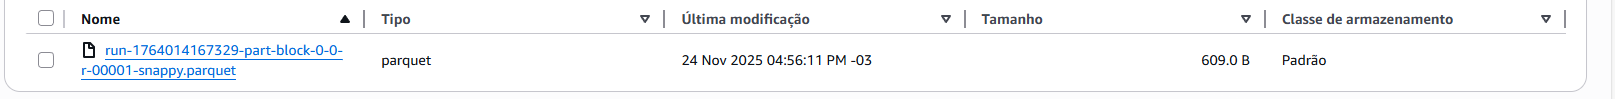

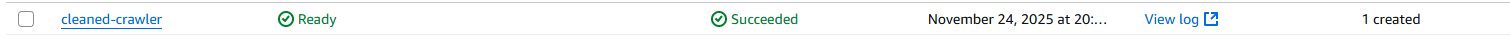

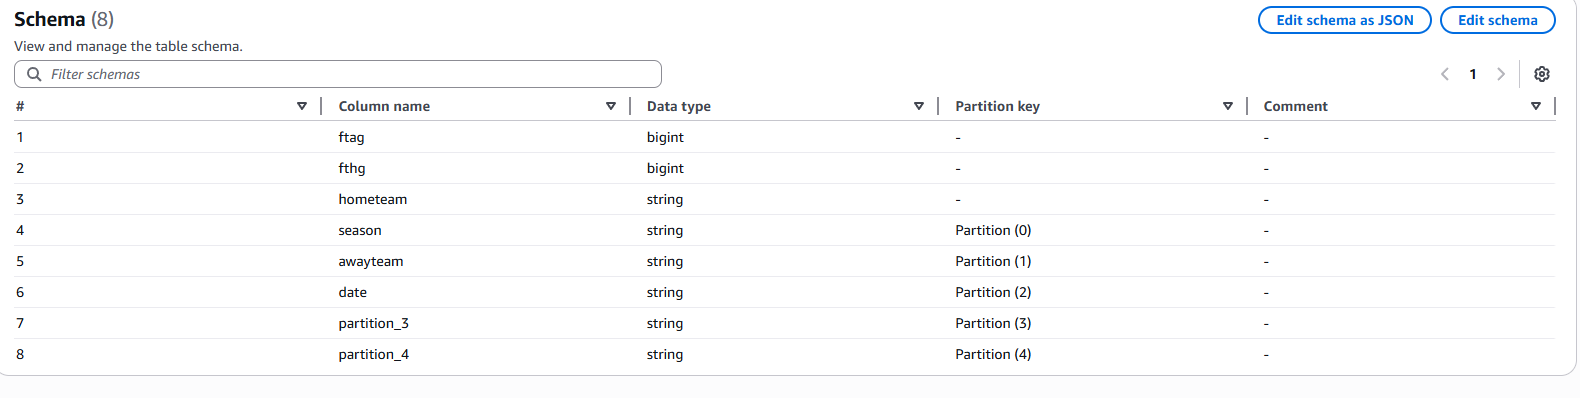

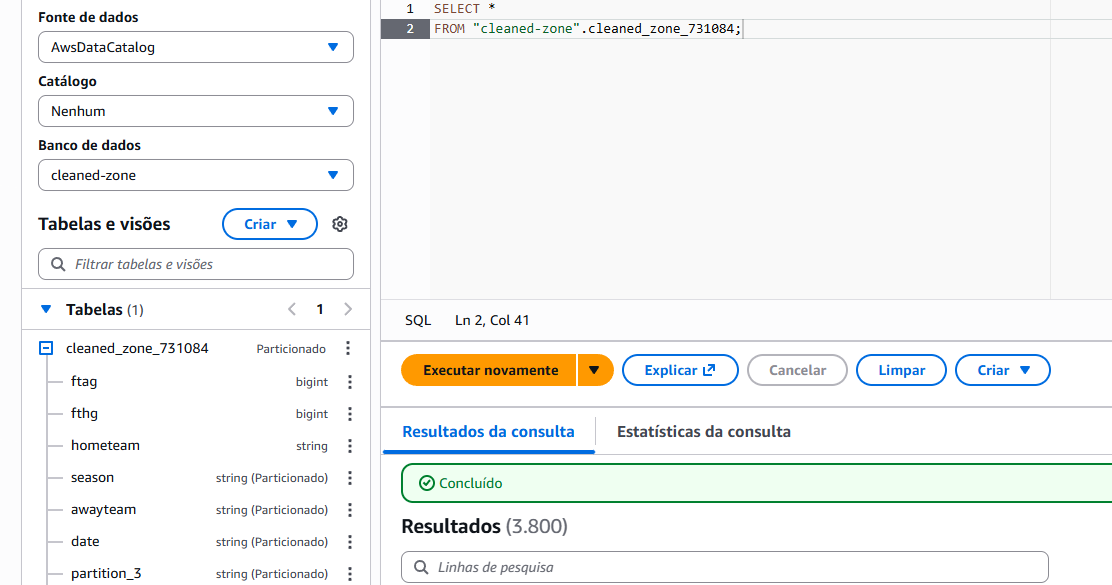

## 4. Curated Zone – Consolidação Analítica
- Consulta da tabela Cleaned no Athena.
- Exportação do CSV.
- Processamento em Python:
  - Cálculo de gols feitos e sofridos.
  - Cálculo de partidas por temporada.
  - Médias gerais, home e away.
- Upload para `cleaned-zone-731084`.
- Novo ETL visual para converter em Parquet e particionar por time.
- Catalogação no curated-zone.

In [ ]:
file_path = '/content/drive/My Drive/Colab Notebooks/'
cleaned_zone_df = pd.read_csv(os.path.join(file_path, 'cleaned zone dataset.csv'))
cleaned_zone_df.head()

,ftag,fthg,hometeam,season,awayteam,date,partition_3,partition_4
0,2,2,Aston Villa,1112,QPR,1,2,12
1,5,0,Wolves,1112,Man United,18,3,12
2,0,1,Liverpool,1213,QPR,19,5,13
3,0,2,Stoke,1112,Fulham,15,10,11
4,0,1,Everton,1213,Fulham,27,4,13


In [ ]:
cleaned_zone_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ftag         3800 non-null   int64 
 1   fthg         3800 non-null   int64 
 2   hometeam     3800 non-null   object
 3   season       3800 non-null   object
 4   awayteam     3800 non-null   object
 5   date         3800 non-null   int64 
 6   partition_3  3800 non-null   int64 
 7   partition_4  3800 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 237.6+ KB


In [ ]:
cleaned_zone_df.isnull().sum()

,0
ftag,0
fthg,0
hometeam,0
season,0
awayteam,0
date,0
partition_3,0
partition_4,0


In [ ]:
df_home = cleaned_zone_df.rename(columns={
    "hometeam": "team",
    "fthg": "gols_feitos",
    "ftag": "gols_sofridos"
}).assign(tipo_jogo="home")

df_away = cleaned_zone_df.rename(columns={
    "awayteam": "team",
    "ftag": "gols_feitos",
    "fthg": "gols_sofridos"
}).assign(tipo_jogo="away")

# Junta home + away empilhando as partidas
df_long = pd.concat([df_home, df_away], ignore_index=True)

# Agora agrupa por time + temporada
df_final = (
    df_long.groupby(["team", "season"])
    .agg(
        total_gols_feitos=("gols_feitos", "sum"),
        total_gols_sofridos=("gols_sofridos", "sum"),
        total_partidas=("team", "count"),
        media_gols_por_partida=("gols_feitos", "mean"),
        media_gols_home=("gols_feitos", lambda x: x[df_long.loc[x.index, "tipo_jogo"] == "home"].mean()),
        media_gols_away=("gols_feitos", lambda x: x[df_long.loc[x.index, "tipo_jogo"] == "away"].mean()),
    )
    .reset_index()
)

df_final

,team,season,total_gols_feitos,total_gols_sofridos,total_partidas,media_gols_por_partida,media_gols_home,media_gols_away
0,Arsenal,1011,72,43,38,1.894737,1.736842,2.052632
1,Arsenal,1112,74,49,38,1.947368,2.052632,1.842105
2,Arsenal,1213,72,37,38,1.894737,2.473684,1.315789
3,Arsenal,1314,68,41,38,1.789474,1.894737,1.684211
4,Arsenal,1415,71,36,38,1.868421,2.157895,1.578947
...,...,...,...,...,...,...,...,...
195,Wigan,S910,37,79,38,0.973684,1.000000,0.947368
196,Wolves,1011,46,66,38,1.210526,1.578947,0.842105
197,Wolves,1112,40,82,38,1.052632,1.000000,1.105263
198,Wolves,1819,47,46,38,1.236842,1.473684,1.000000


In [ ]:
output_path = file_path + 'curated_zone_etl.csv'
df_final.to_csv(output_path, index=False)

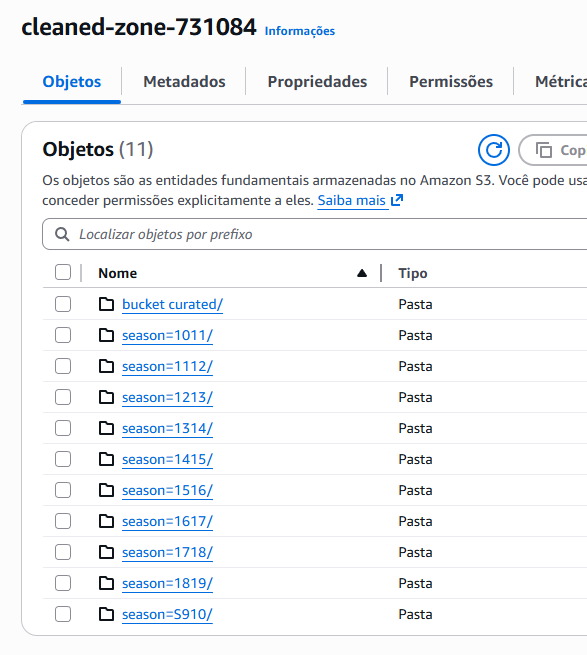

15.PNG

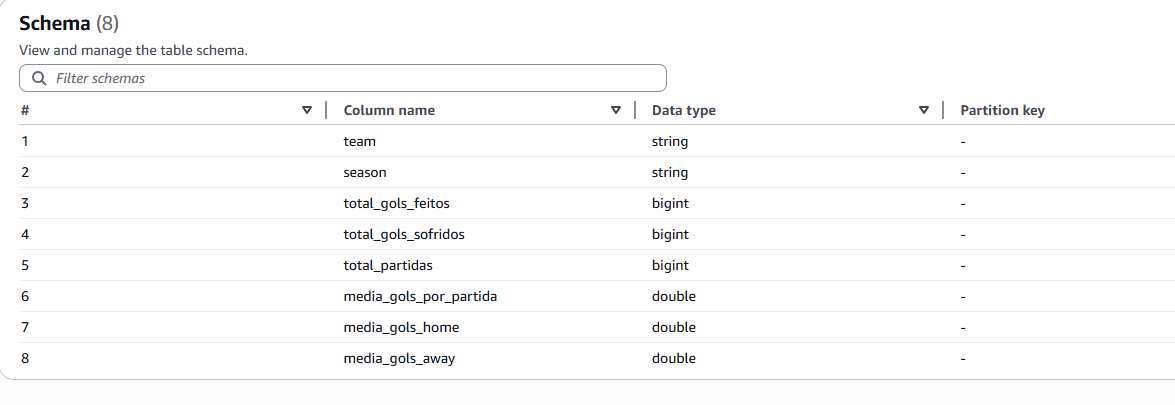

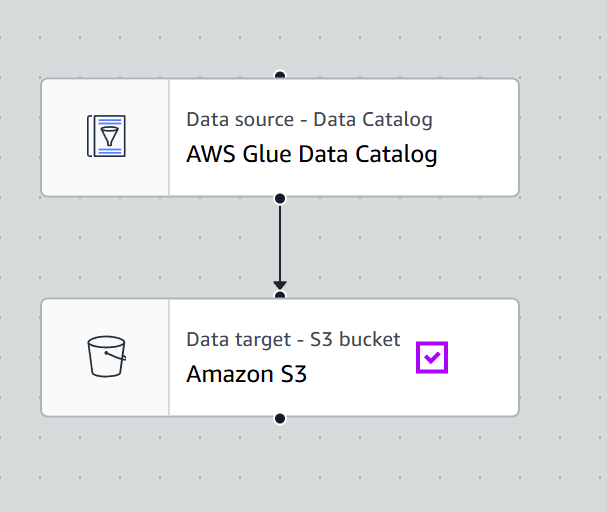

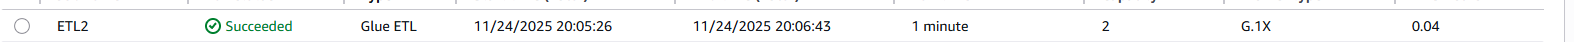

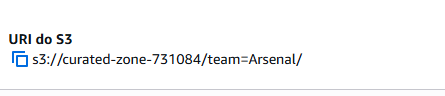

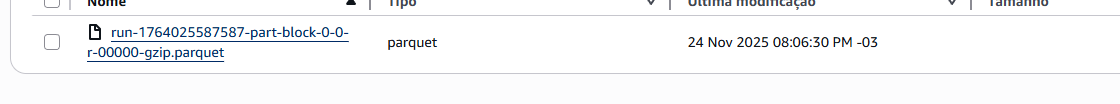

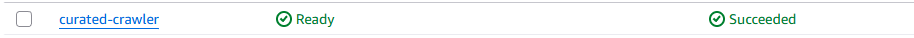

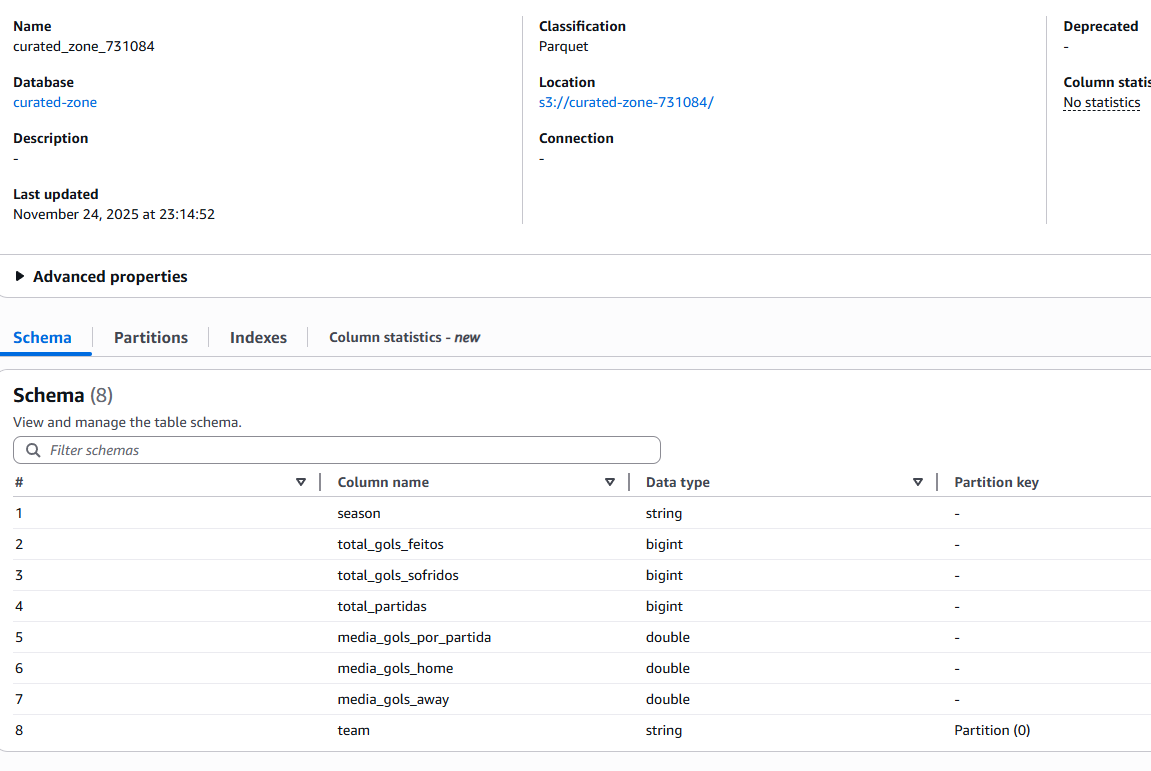

## 5. Consultas no Amazon Athena.

### Equipe com mais gols:

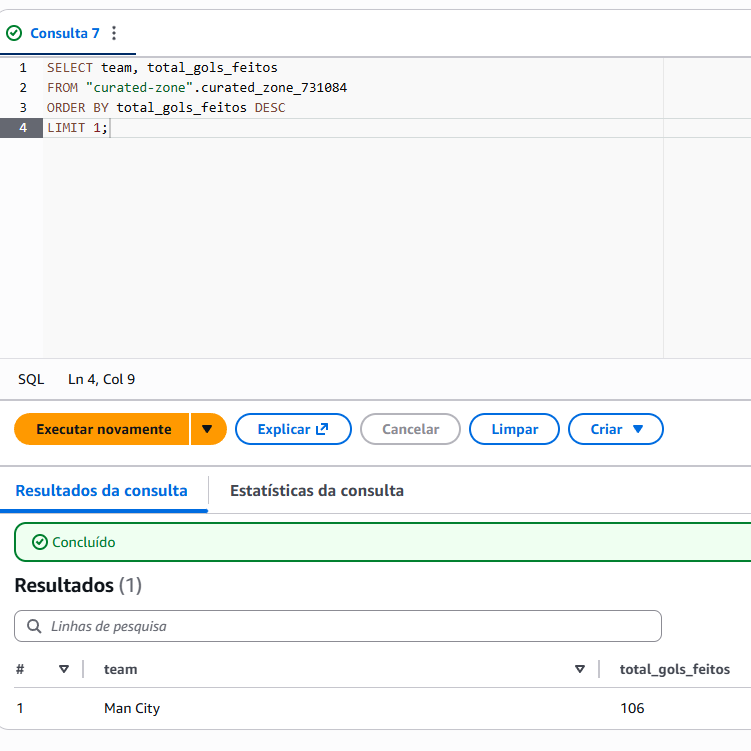

### Equipe com mais gols sofridos:

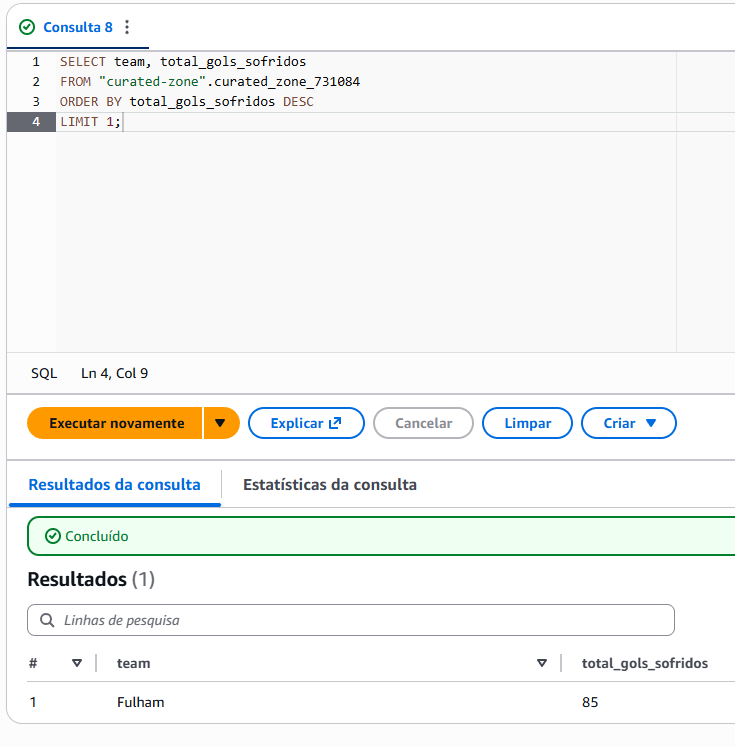

### Média de gols do Manchester United:

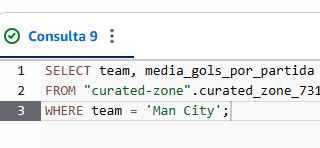

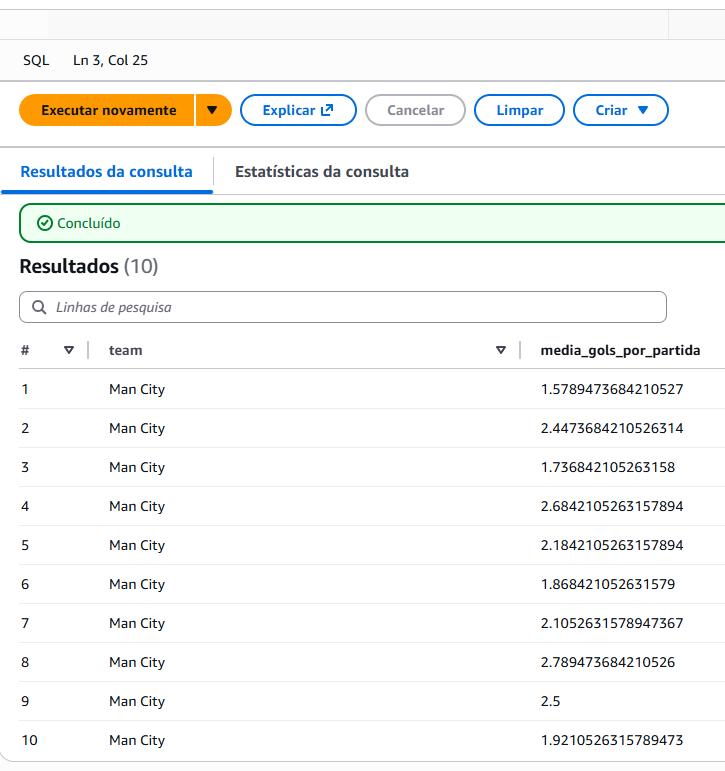

### Média de gols sofridos pelo Liverpool:

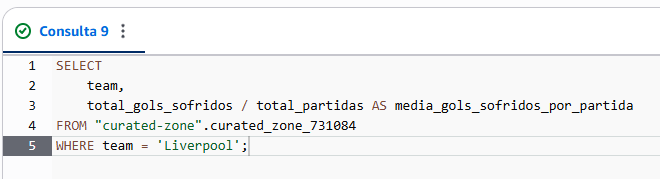

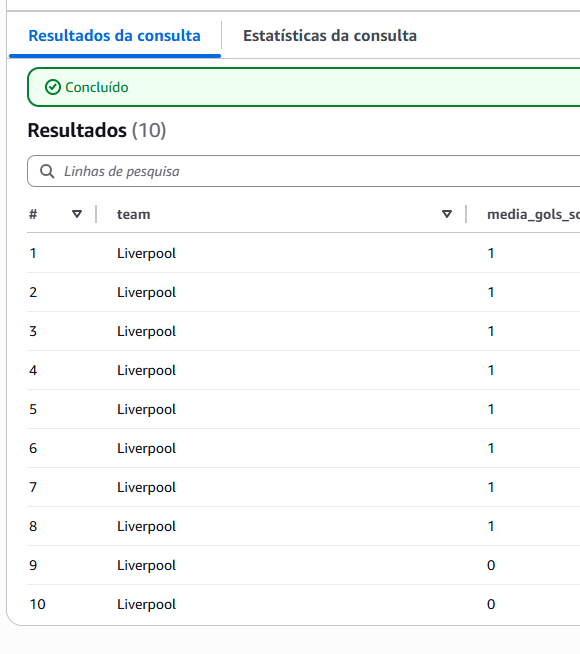

### Melhor ataque:

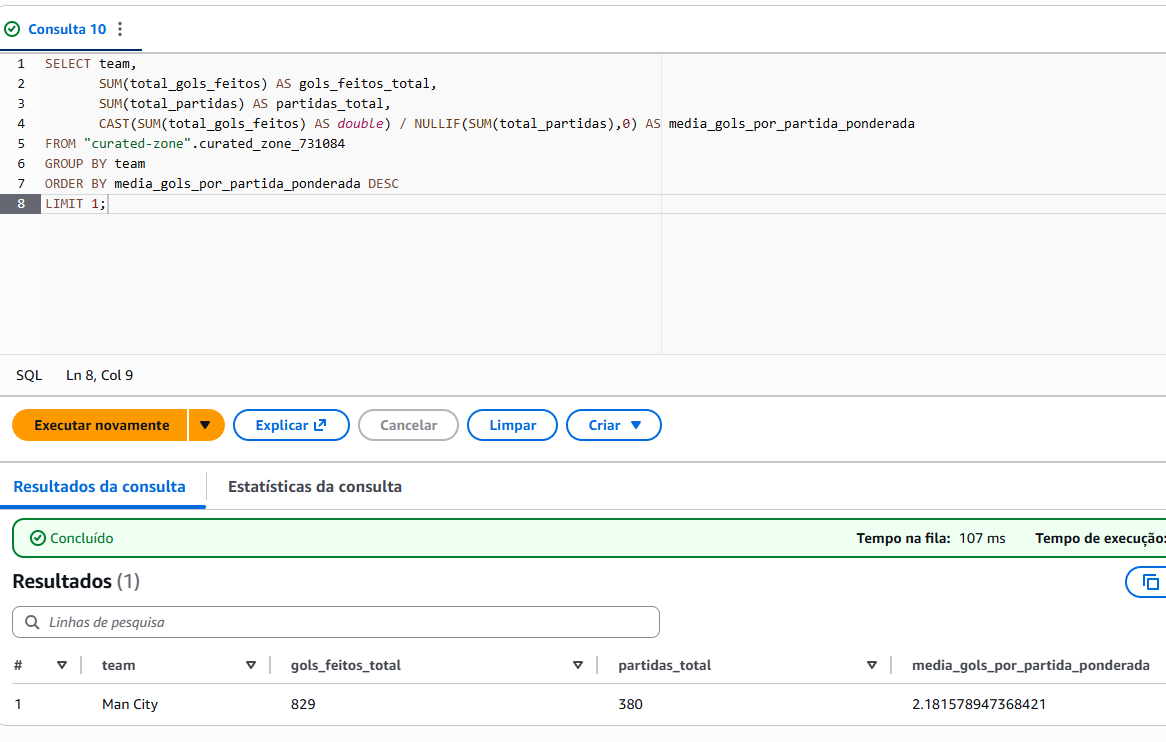

### Pior defesa:

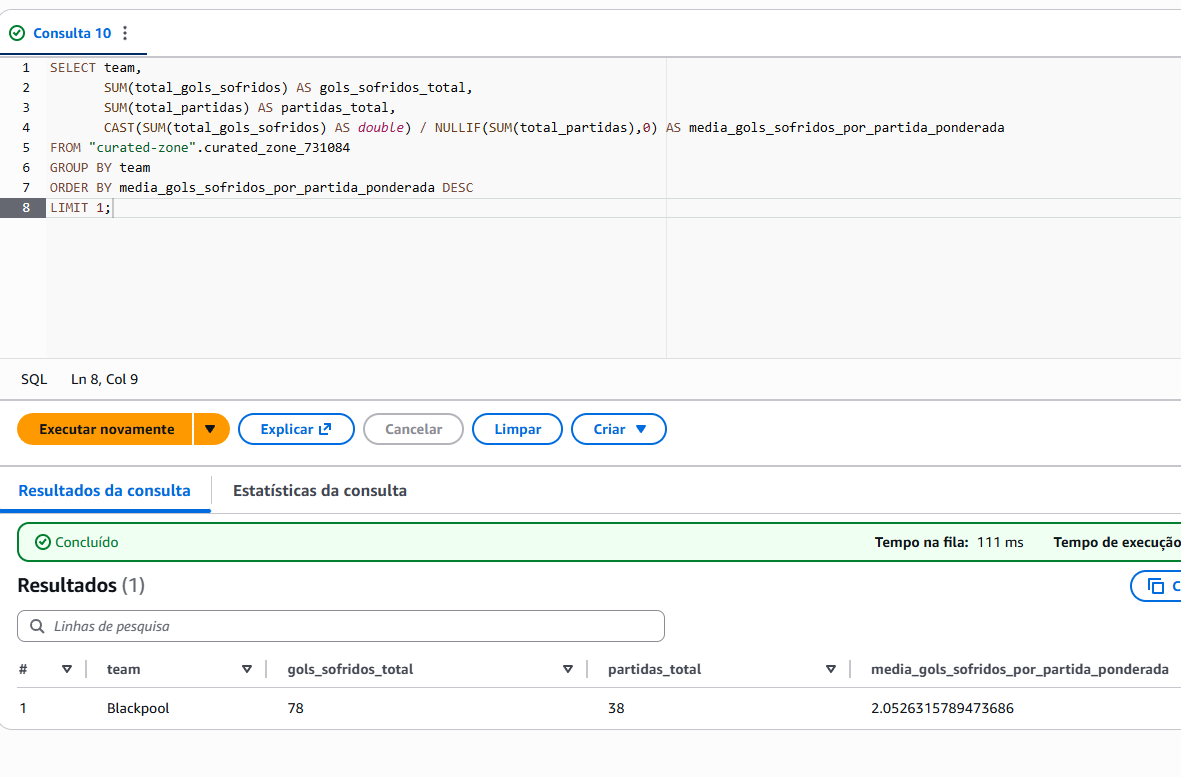

### Melhor ataque por temporada:

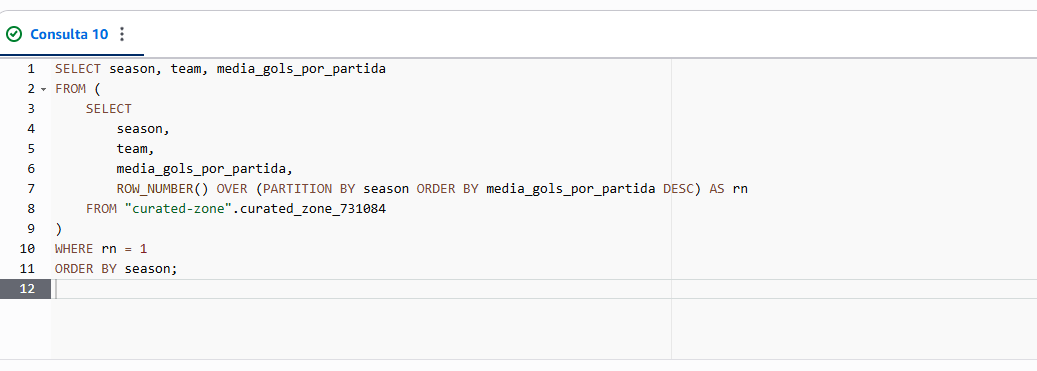

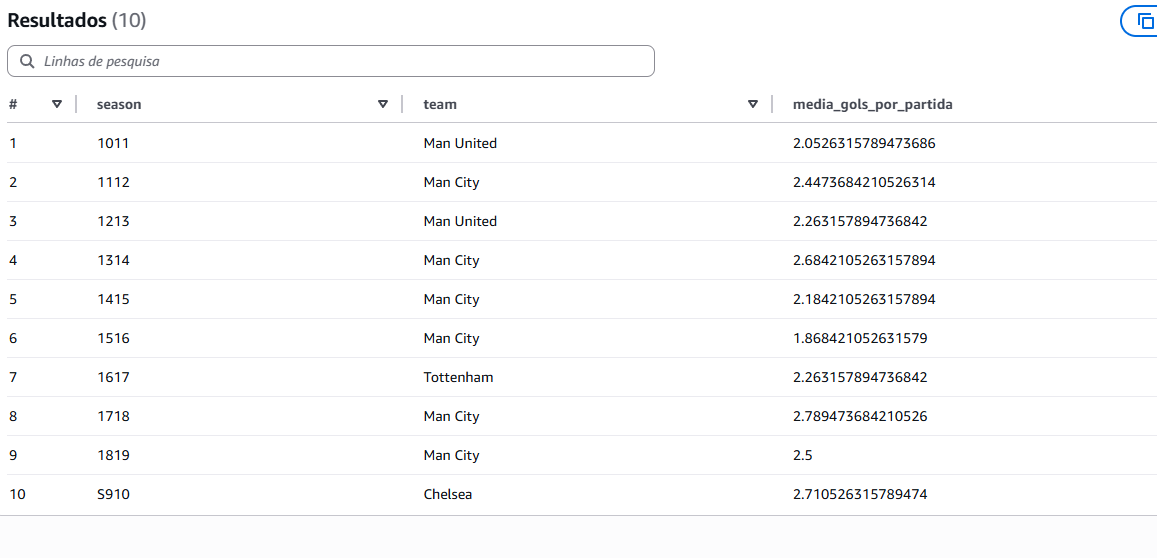